(15509, 10)
<bound method DataFrame.info of                                      Name    Year Duration            Genre  \
0                                             NaN      NaN            Drama   
1      #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                             #Homecoming  (2021)   90 min   Drama, Musical   
3                                 #Yaaram  (2019)  110 min  Comedy, Romance   
4                       ...And Once Again  (2010)  105 min            Drama   
...                                   ...     ...      ...              ...   
15504                 Zulm Ko Jala Doonga  (1988)      NaN           Action   
15505                               Zulmi  (1999)  129 min    Action, Drama   
15506                           Zulmi Raj  (2005)      NaN           Action   
15507                       Zulmi Shikari  (1988)      NaN           Action   
15508                        Zulm-O-Sitam  (1998)  130 min    Action, Drama   

       

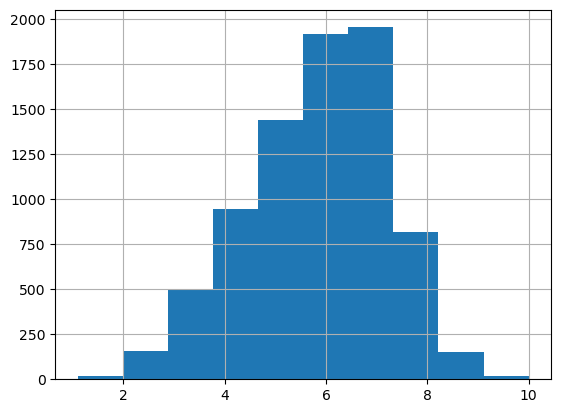

(7919, 10)
(7919, 10)
(7817, 10)
(7812, 10)
(7707, 10)
(7641, 10)
(7558, 10)
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64
Top Genres: Genre
Drama                     1137
Drama, Romance             443
Action, Crime, Drama       417
Action                     391
Drama, Family              291
Action, Drama              270
Comedy                     251
Comedy, Drama              237
Romance                    226
Comedy, Drama, Romance     213
Name: count, dtype: int64
Top Directors (With Min 10 Films)
                      Avg_Rating  Movie_Count
Director                                     
Gulzar                  7.552941           17
Anurag Kashyap          7.400000           13
Bimal Roy               7.286667           15
Shyam Benegal           7.250000           22
Govind Nihalani         7.146154           13
Raj Kapoor              7.145455           11
Hrishikesh Muk

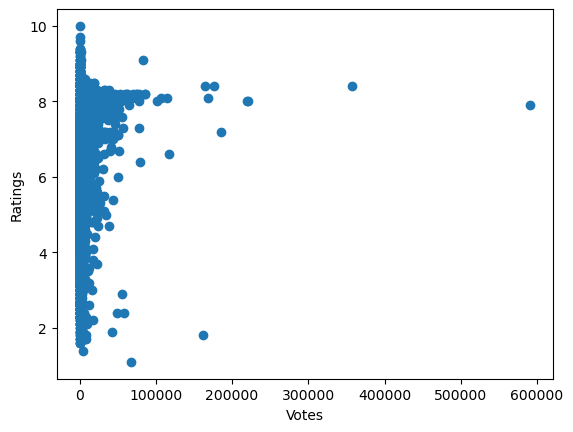

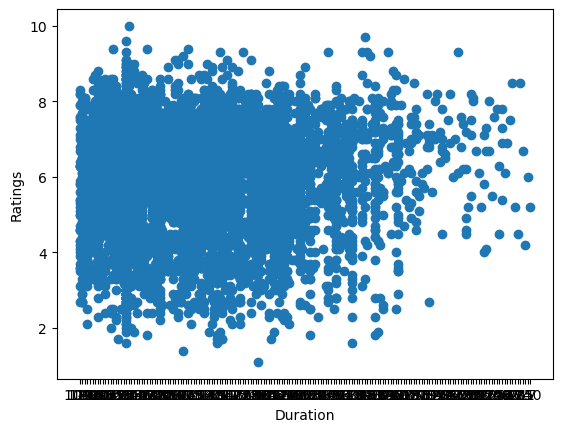

Training Data: (6046, 7)
Testing Data: (1512, 7)
Model Trained Successfully!
[5.84  6.204 6.13  6.189 6.817 5.193 4.982 5.889 6.386 6.567]
MAE : 0.9828994708994707
RMSE: 1.2544940863545004
R² Score: 0.1506241065830356
    Feature  Importance
5     Votes    0.193418
0     Genre    0.166489
2   Actor 1    0.134906
1  Director    0.128894
4   Actor 3    0.128792
3   Actor 2    0.126299
6  Duration    0.121201


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#Loading Dataset
df=pd.read_csv("IMDb_Movies_India.csv", encoding='latin1')
print(df.shape)
print(df.info)
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())


#Exploratory Data Analysis (EDA)
df['Rating'].hist()
plt.savefig("rating_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
#Removing Commas
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
#Removing 'min' from duration
df['Duration']=df['Duration'].astype(str).str.replace('min','')
#Removing Missing Ratings
df=df.dropna(subset=['Rating'])
print(df.shape)
#Removing Missing Duration
df=df.dropna(subset=['Duration'])
print(df.shape)
#Removing Missing Genre
df=df.dropna(subset=['Genre'])
print(df.shape)
#Removing Missing Director
df=df.dropna(subset=['Director'])
print(df.shape)
#Removing Missing Actors
df=df.dropna(subset=['Actor 1'])
print(df.shape)

df=df.dropna(subset=['Actor 2'])
print(df.shape)

df=df.dropna(subset=['Actor 3'])
print(df.shape)
print(df.isnull().sum())

#Statistics
#Top Genres
print("Top Genres:",df['Genre'].value_counts().head(10))
director_stats=df.groupby('Director').agg({
    'Rating':'mean',
    'Name':'count'
})
#Top Directors (With Min 10 Films)
print("Top Directors (With Min 10 Films)")
director_stats.columns=['Avg_Rating','Movie_Count']
print(director_stats[director_stats['Movie_Count']>10].sort_values('Avg_Rating',ascending=False).head(10))
#Highest Rated Genres
print("Highest Rated Genres:")
genre_rating=df.groupby('Genre')['Rating'].mean()
print(genre_rating.sort_values(ascending=False).head(10))
all_actors=pd.concat([
    df['Actor 1'],
    df['Actor 2'],
    df['Actor 3']
])
#Actors With Most Films (With Min 50 Films)
print("Actors with Most Films:\n",all_actors.value_counts().head(10))

actors_stats=df.groupby('Actor 1').agg({
    'Rating':'mean',
    'Name':'count'
})
print("Top Leading Actors (With Min 50 Films):\n")
actors_stats.columns=['Avg_Rating','Movie_Count']
print(actors_stats[actors_stats['Movie_Count']>50].sort_values('Avg_Rating',ascending=False).head(10))

#Visualization and Insights
#Voters vs Rating
plt.scatter(df['Votes'], df['Rating'])
plt.xlabel('Votes')
plt.ylabel('Ratings')
plt.savefig("votes_vs_ratings.png", dpi=300, bbox_inches='tight')
plt.show()
#Duration vs Rating
plt.scatter(df['Duration'], df['Rating'])
plt.xlabel('Duration')
plt.ylabel('Ratings')
plt.savefig("duration_vs_ratings.png", dpi=300, bbox_inches='tight')
plt.show()

#Training Model (RandomForest)
#Step 1 :Encoding Categorical Columns
cat_cols=['Genre','Director','Actor 1','Actor 2','Actor 3']
for col in cat_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str))

#Step 2: Creating X and y
X = df[['Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3',
        'Votes',
        'Duration']]

y = df['Rating']
#Step 3: Splitting Dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data:",X_train.shape)
print("Testing Data:",X_test.shape)
#Step 4: Train Random Forest Model
model=RandomForestRegressor(
    n_estimators=100,
    random_state=42)
model.fit(X_train,y_train)
print("Model Trained Successfully!")
#Step 5: Prediction
y_pred=model.predict(X_test)
print(y_pred[:10])
#Step 6: Evaulute the Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
#Step 7: Feature Importance
importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance)